# Predicting F1 Tyre Degradation to Optimize Pit Stop Strategy
**Kevin Zong (115265318) & Michael Obajemu (114202291)**

Midterm checkpoint. So far we have:
- A pipeline that pulls and caches 2024 & 2025 F1 season data from FastF1
- Data cleaning process to remove the non-regular data such as safety car laps, in/out laps, and anomalies
- Added new features: fuel-corrected lap time, lap time delta, tyre-life ratio
- Exploratory visualizations: distributions, degradation curves by compound, correlation matrix

In [22]:
# !pip install fastf1

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
import logging

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

fastf1.Cache.enable_cache('fastf1_cache')

print('Dependencies loaded successfully.')

Dependencies loaded successfully.


## 1. Data Collection

First, we'll pull race data from the 2024 season (training set) and 2025 season (validation set). Each season has 24 races and approximately 50,000 laps (rows) total. Each row contains lap time, tyre compound, tyre life, stint number, pit events, and weather conditions. Both seasons share the same set of circuits.

**Note:** The first run downloads and caches data locally so subsequent runs are much faster.

In [23]:
ROUNDS = [
    (2024, 1,  'Bahrain'),
    (2024, 2,  'Saudi Arabia'),
    (2024, 3,  'Australia'),
    (2024, 4,  'Japan'),
    (2024, 5,  'China'),
    (2024, 6,  'Miami'),
    (2024, 7,  'Emilia Romagna'),
    (2024, 8,  'Monaco'),
    (2024, 9,  'Canada'),
    (2024, 10, 'Spain'),
    (2024, 11, 'Austria'),
    (2024, 12, 'Great Britain'),
    (2024, 13, 'Hungary'),
    (2024, 14, 'Belgium'),
    (2024, 15, 'Netherlands'),
    (2024, 16, 'Italy'),
    (2024, 17, 'Azerbaijan'),
    (2024, 18, 'Singapore'),
    (2024, 19, 'United States'),
    (2024, 20, 'Mexico'),
    (2024, 21, 'Brazil'),
    (2024, 22, 'Las Vegas'),
    (2024, 23, 'Qatar'),
    (2024, 24, 'Abu Dhabi'),
    (2025, 1,  'Australia'),
    (2025, 2,  'China'),
    (2025, 3,  'Japan'),
    (2025, 4,  'Bahrain'),
    (2025, 5,  'Saudi Arabia'),
    (2025, 6,  'Miami'),
    (2025, 7,  'Emilia Romagna'),
    (2025, 8,  'Monaco'),
    (2025, 9,  'Spain'),
    (2025, 10, 'Canada'),
    (2025, 11, 'Austria'),
    (2025, 12, 'Great Britain'),
    (2025, 13, 'Belgium'),
    (2025, 14, 'Hungary'),
    (2025, 15, 'Netherlands'),
    (2025, 16, 'Italy'),
    (2025, 17, 'Azerbaijan'),
    (2025, 18, 'Singapore'),
    (2025, 19, 'United States'),
    (2025, 20, 'Mexico'),
    (2025, 21, 'Brazil'),
    (2025, 22, 'Las Vegas'),
    (2025, 23, 'Qatar'),
    (2025, 24, 'Abu Dhabi'),
]

all_laps = []
logging.getLogger('fastf1').setLevel(logging.ERROR)

for year, rnd, name in ROUNDS:
    try:
        session = fastf1.get_session(year, rnd, 'R')
        # we only need laps and weather, so we'll skip telemetry and messages to speed up loading
        session.load(telemetry=False, weather=True, messages=False)
        laps = session.laps.copy()
        laps['Race']  = name
        laps['Year']  = year
        laps['Round'] = rnd

        if session.weather_data is not None and not session.weather_data.empty:
            laps['AirTemp']   = session.weather_data['AirTemp'].mean()
            laps['TrackTemp'] = session.weather_data['TrackTemp'].mean()
        else:
            laps['AirTemp']   = np.nan
            laps['TrackTemp'] = np.nan

        all_laps.append(laps)
        print(f'  Loaded {name} {year}: {len(laps)} laps')
    except Exception as e:
        print(f'  Failed to load {name} {year}: {e}')

raw_df = pd.concat(all_laps, ignore_index=True)
print(f'\nRaw dataset: {len(raw_df)} laps across {raw_df["Race"].nunique()} races')

  Loaded Bahrain 2024: 1129 laps
  Loaded Saudi Arabia 2024: 901 laps
  Loaded Australia 2024: 998 laps
  Loaded Japan 2024: 907 laps
  Loaded China 2024: 1032 laps
  Loaded Miami 2024: 1111 laps
  Loaded Emilia Romagna 2024: 1238 laps
  Loaded Monaco 2024: 1237 laps
  Loaded Canada 2024: 1272 laps
  Loaded Spain 2024: 1310 laps
  Loaded Austria 2024: 1405 laps
  Loaded Great Britain 2024: 961 laps
  Loaded Hungary 2024: 1355 laps
  Loaded Belgium 2024: 841 laps
  Loaded Netherlands 2024: 1426 laps
  Loaded Italy 2024: 1008 laps
  Loaded Azerbaijan 2024: 973 laps
  Loaded Singapore 2024: 1177 laps
  Loaded United States 2024: 1059 laps
  Loaded Mexico 2024: 1215 laps
  Loaded Brazil 2024: 1135 laps
  Loaded Las Vegas 2024: 938 laps
  Loaded Qatar 2024: 943 laps
  Loaded Abu Dhabi 2024: 1035 laps
  Loaded Australia 2025: 927 laps
  Loaded China 2025: 1065 laps
  Loaded Japan 2025: 1059 laps
  Loaded Bahrain 2025: 1128 laps
  Loaded Saudi Arabia 2025: 898 laps
  Loaded Miami 2025: 1005 l

Request for URL https://api.jolpi.ca/ergast/f1/2025/12/results.json failed; using cached response
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.11/site-packages/requests_cache/session.py", line 316, in _resend
    response.raise_for_status()
  File "/opt/homebrew/lib/python3.11/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://api.jolpi.ca/ergast/f1/2025/12/results.json
Request for URL https://api.jolpi.ca/ergast/f1/2025/12/laps/1.json failed; using cached response
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.11/site-packages/requests_cache/session.py", line 316, in _resend
    response.raise_for_status()
  File "/opt/homebrew/lib/python3.11/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 

  Loaded Great Britain 2025: 826 laps


Request for URL https://api.jolpi.ca/ergast/f1/2025/13/laps/1.json failed; using cached response
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.11/site-packages/requests_cache/session.py", line 316, in _resend
    response.raise_for_status()
  File "/opt/homebrew/lib/python3.11/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://api.jolpi.ca/ergast/f1/2025/13/laps/1.json


  Loaded Belgium 2025: 879 laps


...

  Loaded Las Vegas 2025: 886 laps


Request for URL https://api.jolpi.ca/ergast/f1/2025/23/results.json failed; using cached response
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.11/site-packages/requests_cache/session.py", line 316, in _resend
    response.raise_for_status()
  File "/opt/homebrew/lib/python3.11/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://api.jolpi.ca/ergast/f1/2025/23/results.json
Request for URL https://api.jolpi.ca/ergast/f1/2025/23/laps/1.json failed; using cached response
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.11/site-packages/requests_cache/session.py", line 316, in _resend
    response.raise_for_status()
  File "/opt/homebrew/lib/python3.11/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 

  Loaded Qatar 2025: 1067 laps


Request for URL https://api.jolpi.ca/ergast/f1/2025/24/results.json failed; using cached response
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.11/site-packages/requests_cache/session.py", line 316, in _resend
    response.raise_for_status()
  File "/opt/homebrew/lib/python3.11/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://api.jolpi.ca/ergast/f1/2025/24/results.json
Request for URL https://api.jolpi.ca/ergast/f1/2025/24/laps/1.json failed; using cached response
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.11/site-packages/requests_cache/session.py", line 316, in _resend
    response.raise_for_status()
  File "/opt/homebrew/lib/python3.11/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 

  Loaded Abu Dhabi 2025: 1156 laps

Raw dataset: 53298 laps across 24 races


## 2. Data Cleaning

We chose to remove laps that we feel don't reflect genuine tyre degradation:
- **In-laps / out-laps** - speed limits are enforced distortig lap times
- **Safety car / Virtual Safety Car (VSC) / red flag laps** - speed is also capped in these
- **Wet/intermediate compounds** — out of scope for this model
- **Statistical outliers** — laps with times > 3 std deviations from per-race mean. These extreme times are usually caused by factors like spins or collisions rather than tyre degradation
- **Missing key fields** - lap time, tyre life, compound, driver

In [24]:
df = raw_df.copy()
print(f'Laps before cleaning: {len(df)}')

# Only keep laps where the driver didn't enter or exit the pit lane
df = df[df['PitInTime'].isna() & df['PitOutTime'].isna()]

# Remove laps with status codes 4 (safety car), 5 (VSC), 6 (red flag)
if 'TrackStatus' in df.columns:
    df = df[~df['TrackStatus'].astype(str).str.contains('4|5|6', na=False)]

# Filter out wet/intermediate compounds
df = df[df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]

# Drop rows missing key fields
df = df.dropna(subset=['LapTime', 'TyreLife', 'Compound', 'Driver'])

# Convert LapTime to seconds, drop erroneous laps
df['LapTimeSec'] = df['LapTime'].dt.total_seconds()
df = df[df['LapTimeSec'] > 60]

cols_to_drop = [
    # Dropping artifacts no longer needed
    'PitInTime', 'PitOutTime', 'TrackStatus', 'LapTime', 'Round', 'DriverNumber',
    'Time', 'LapStartTime', 'LapStartDate',
    # Dropping sector splits
    'Sector1Time', 'Sector2Time', 'Sector3Time',
    'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
    # Dropping Metadata flags
    'IsPersonalBest', 'Deleted', 'DeletedReason', 'FastF1Generated',
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# drop initial standing start on cold tyre's, starts are filled with chaos and not helping in degradation modeling
df = df[df['LapNumber'] > 1]

# drop unreliable timing data
df = df[df['IsAccurate'] == True]

print(f'Laps after cleaning:  {len(df)}')


Laps before cleaning: 53298
Laps after cleaning:  43319


## 3. Feature Engineering


- `LapTimeDelta`: Lap time minus per-driver per-stint median — captures degradation relative to each driver's fresh pace
- `FuelCorrectedLap`: What a car's lap time would be if it were running on a standardized fuel load (usually empty or full) (adjusts ~0.03s per lap)
- `TyreLifeRatio`: Tyre life normalized 0–1 within each stint
- `CompoundEncoded`: Ordinal: SOFT=0, MEDIUM=1, HARD=2
- `StintLength`: Total laps in that driver's stint

In [25]:
# Lap time delta relative to each driver's per-stint median
stint_medians = df.groupby(['Race', 'Driver', 'Stint'])['LapTimeSec'].transform('median')
df['LapTimeDelta'] = df['LapTimeSec'] - stint_medians

# Fuel correction
df['FuelCorrectedLap'] = df['LapTimeSec'] - (0.03 * df['LapNumber'])

# Tyre life ratio within each stint
stint_max_life = df.groupby(['Race', 'Driver', 'Stint'])['TyreLife'].transform('max')
df['TyreLifeRatio'] = df['TyreLife'] / stint_max_life.replace(0, np.nan)

# Compound encoding
df['CompoundEncoded'] = df['Compound'].map({'SOFT': 0, 'MEDIUM': 1, 'HARD': 2})

# Stint length
df['StintLength'] = df.groupby(['Race', 'Driver', 'Stint'])['LapTimeSec'].transform('count')

print(f'Dataset shape after adding features: {df.shape}')
df[['Race', 'Year', 'Driver', 'Compound', 'TyreLife', 'LapTimeSec',
    'LapTimeDelta', 'FuelCorrectedLap', 'TyreLifeRatio', 'CompoundEncoded',
    'StintLength']].head(10)

Dataset shape after adding features: (43319, 23)


,Race,Year,Driver,Compound,TyreLife,LapTimeSec,LapTimeDelta,FuelCorrectedLap,TyreLifeRatio,CompoundEncoded,StintLength
1,Bahrain,2024,VER,SOFT,5.0,96.296,-0.796,96.236,0.263158,0,23
2,Bahrain,2024,VER,SOFT,6.0,96.753,-0.339,96.663,0.315789,0,23
3,Bahrain,2024,VER,SOFT,7.0,96.647,-0.445,96.527,0.368421,0,23
4,Bahrain,2024,VER,SOFT,8.0,97.173,0.081,97.023,0.421053,0,23
5,Bahrain,2024,VER,SOFT,9.0,97.092,0.000,96.912,0.473684,0,23
6,Bahrain,2024,VER,SOFT,10.0,97.038,-0.054,96.828,0.526316,0,23
7,Bahrain,2024,VER,SOFT,11.0,97.024,-0.068,96.784,0.578947,0,23
8,Bahrain,2024,VER,SOFT,12.0,97.229,0.137,96.959,0.631579,0,23
9,Bahrain,2024,VER,SOFT,13.0,96.960,-0.132,96.660,0.684211,0,23
10,Bahrain,2024,VER,SOFT,14.0,97.085,-0.007,96.755,0.736842,0,23


## 4. Exploratory Visualizations

### 4.1 Tyre Life Distribution by Compound

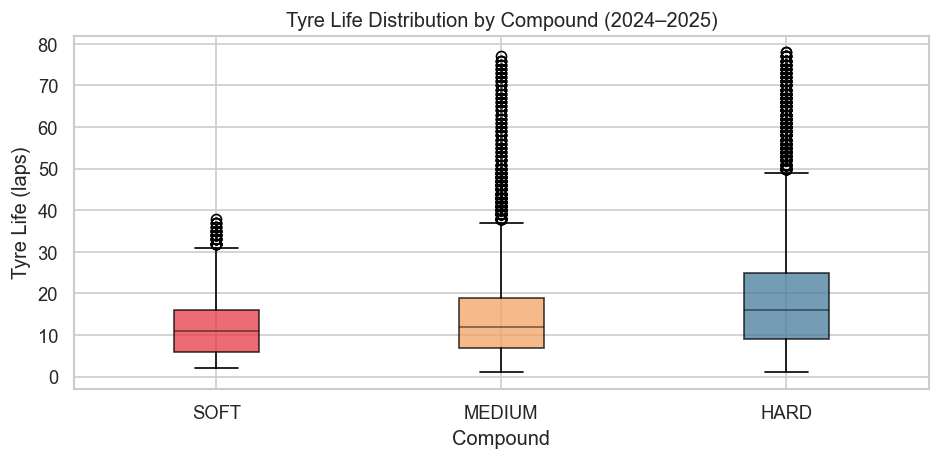

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

compounds = ['SOFT', 'MEDIUM', 'HARD']
colors = ['#e63946', '#f4a261', '#457b9d']
data = [df[df['Compound'] == c]['TyreLife'].dropna() for c in compounds]

bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color='black', alpha=0.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(compounds)
ax.set_xlabel('Compound')
ax.set_ylabel('Tyre Life (laps)')
ax.set_title('Tyre Life Distribution by Compound (2024–2025)')
plt.tight_layout()
plt.savefig('plot_01_tyre_life_dist.png', bbox_inches='tight')
plt.show()

**Interpretation**

SOFT tyres have the shortest median stint (~10 laps) and tightest IQR, reflecting their limited durability. HARD tyres show the highest median (~15 laps) and widest IQR, consistent with flexible long-stint usage. MEDIUM sits between the two in median but has extensive outliers reaching 70+ laps — likely anomalous stints (e.g., drivers staying out under unusual race circumstances) that should be investigated during modeling. Both MEDIUM and HARD show heavy upper-tail outliers, suggesting stint length filtering (e.g., capping at 40–50 laps) may be needed to prevent extreme stints from skewing the degradation model.

### 4.2 Distribution of Lap Times & Mean LapTime Delta

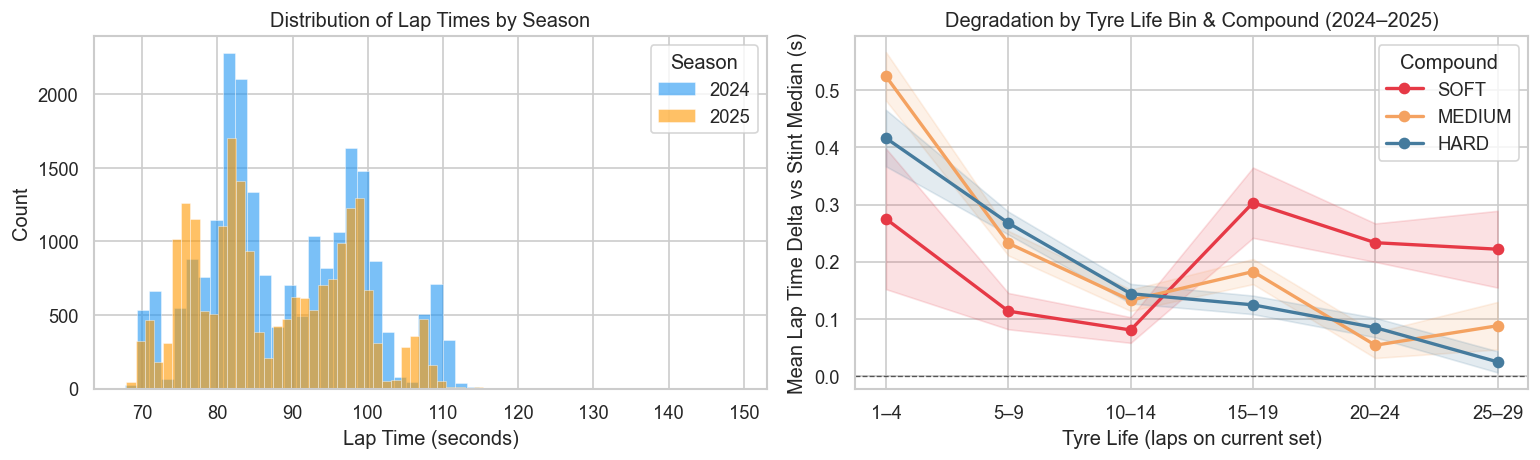

In [30]:
compound_colors = {'SOFT': '#e63946', 'MEDIUM': '#f4a261', 'HARD': '#457b9d'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Lap time histogram, shaded by season
for year, color in [(2024, '#2196F3'), (2025, '#FF9800')]:
    subset = df[df['Year'] == year]['LapTimeSec']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, edgecolor='white',
                 linewidth=0.4, label=str(year))
axes[0].set_xlabel('Lap Time (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Lap Times by Season')
axes[0].legend(title='Season')

# Mean LapTimeDelta by tyre life bin, per compound
bin_edges  = [1, 5, 10, 15, 20, 25, 30]
bin_labels = ['1–4', '5–9', '10–14', '15–19', '20–24', '25–29']
df['_LifeBin'] = pd.cut(df['TyreLife'], bins=bin_edges, labels=bin_labels, right=False)

for i, (compound, color) in enumerate(compound_colors.items()):
    sub    = df[df['Compound'] == compound].groupby('_LifeBin', observed=True)['LapTimeDelta']
    means  = sub.mean()
    stderr = sub.sem()
    x      = range(len(means))
    axes[1].plot(x, means.values, marker='o', label=compound, color=color, linewidth=2)
    axes[1].fill_between(x,
                         means.values - stderr.values,
                         means.values + stderr.values,
                         alpha=0.15, color=color)

axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
axes[1].set_xlabel('Tyre Life (laps on current set)')
axes[1].set_ylabel('Mean Lap Time Delta vs Stint Median (s)')
axes[1].set_title('Degradation by Tyre Life Bin & Compound (2024–2025)')
axes[1].legend(title='Compound')

df = df.drop(columns=['_LifeBin'])


plt.tight_layout()
plt.savefig('plot_02_distributions.png', bbox_inches='tight')
plt.show()

**Interpretation**

*Left visual*

Both 2024 and 2025 distributions are nearly identical in shape, peaking around 85–90s. This is a good sign for our train/test split. The two seasons have the same underlying distribution, so a model trained on 2024 won't face distribution shift when validated on 2025.

*Right visual*

Each compound shows mean lap time increases (gets slower) as tyre life progresses:

- SOFT (red): Fastest decline in performance over ~10 laps. Also the most volatile (widest error bands), reflecting more driver-to-driver and race-to-race variation in soft-tyre strategies.
- MEDIUM (orange): More gradual slowdown over 10–20 laps, with tighter confidence bands than soft. More predictable performance.
- HARD (blue): Minimal degradation over 25+ laps. Hard tyres maintain pace much longer but start from a slower baseline. Narrow error bands suggest consistent behavior.

### 4.3 Degradation Rate Heatmap (compound × circuit)

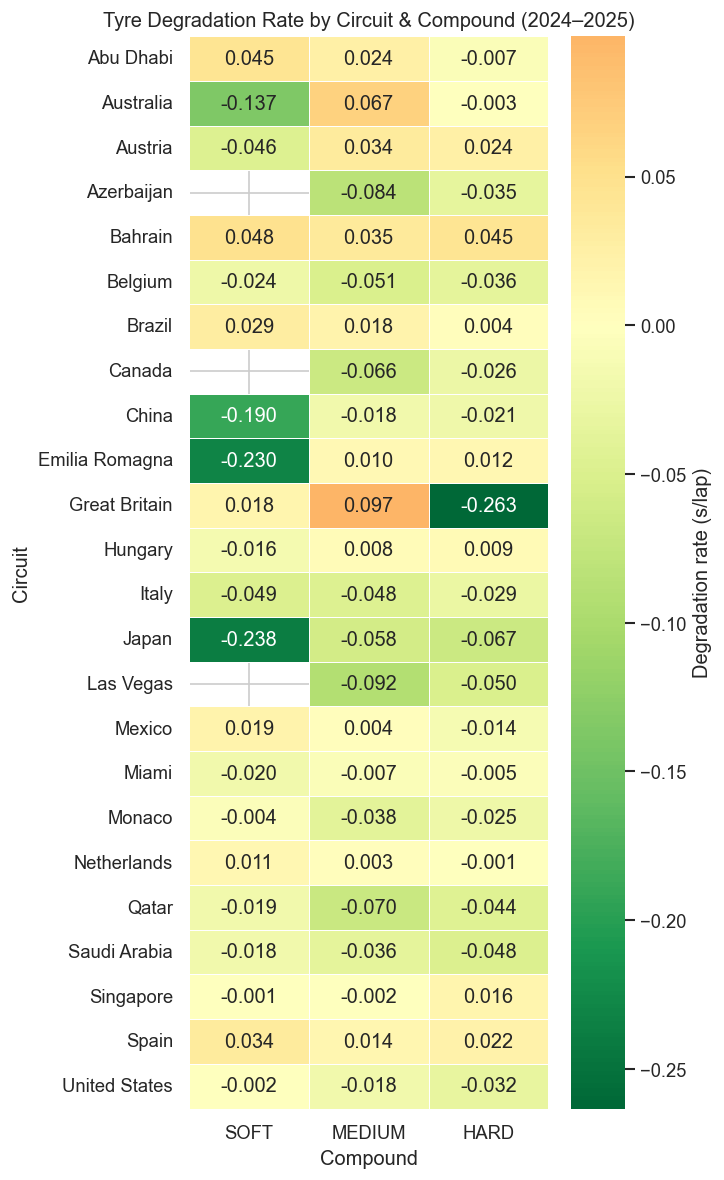

In [ ]:
from numpy.polynomial import polynomial as P

compounds = ['SOFT', 'MEDIUM', 'HARD']
circuits  = sorted(df['Race'].unique())

# Compute degradation slope (s/lap) for each circuit-compound pair
slopes = {}
for circuit in circuits:
    for compound in compounds:
        sub = df[(df['Race'] == circuit) & (df['Compound'] == compound)]
        if len(sub) >= 10:
            coef = np.polyfit(sub['TyreLife'], sub['LapTimeDelta'], 1)
            slopes[(circuit, compound)] = round(coef[0], 4)
        else:
            slopes[(circuit, compound)] = np.nan

slope_df = pd.DataFrame(
    {c: [slopes.get((r, c), np.nan) for r in circuits] for c in compounds},
    index=circuits
)

fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(slope_df, annot=True, fmt='.3f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Degradation rate (s/lap)'})
ax.set_title('Tyre Degradation Rate by Circuit & Compound (2024–2025)')
ax.set_xlabel('Compound')
ax.set_ylabel('Circuit')
plt.tight_layout()
plt.savefig('plot_03_degradation_heatmap.png', bbox_inches='tight')
plt.show()

**Interpretation**

The heatmap reveals two key insights:

1. SOFT always degrades fastest and HARD slowest across all circuits.
1.  Degradation rates vary significantly by track. High grip, high cornering circuits (Monaco, Hungary, Singapore) show orange/yellow across all compounds — tyres work harder and age faster. Low-stress circuits (Monza, Spa) show more green values — tyres hold pace longer. This means our your model needs circuit context. When modeling circuit will need to be added as a categorical feature. For strategy optimization, we may need to pre-compute degradation curves per circuit to avoid less than ideal compound decisions.

### 4.4 Correlation Matrix

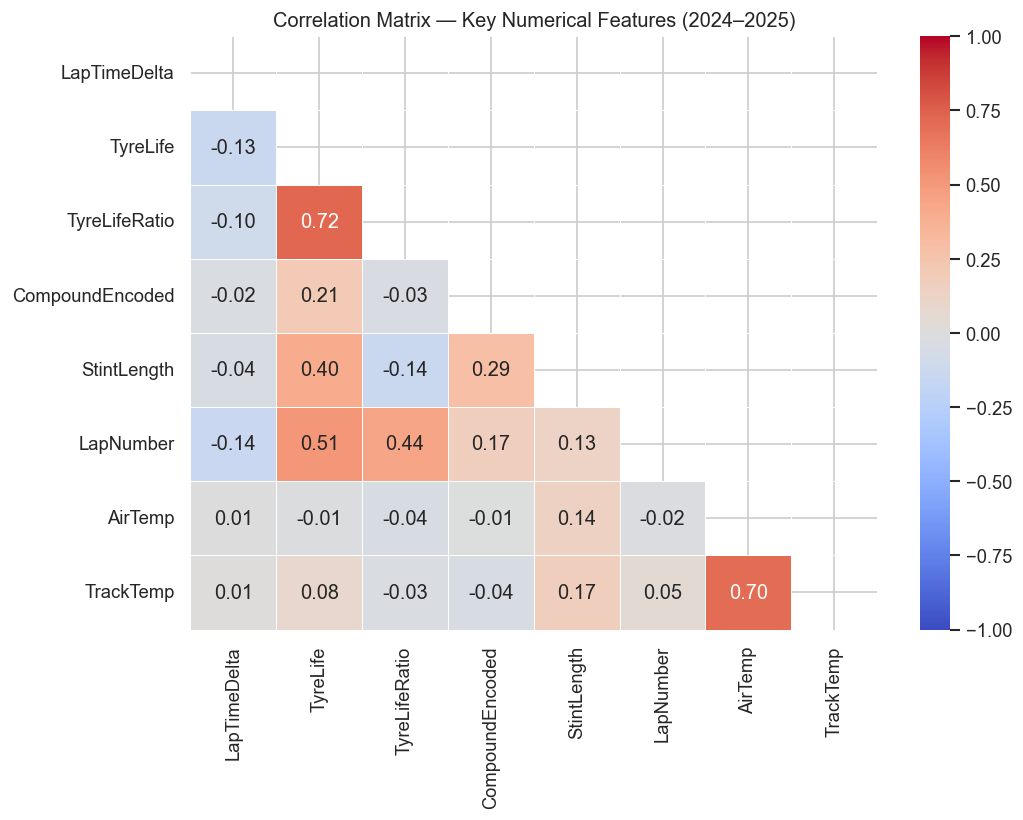

In [ ]:
corr_features = [
    'LapTimeDelta', 'TyreLife', 'TyreLifeRatio', 'CompoundEncoded',
    'StintLength', 'LapNumber', 'AirTemp', 'TrackTemp'
]

corr_matrix = df[corr_features].dropna().corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Key Numerical Features (2024–2025)')
plt.tight_layout()
plt.savefig('plot_04_correlation_matrix.png', bbox_inches='tight')
plt.show()

**Interpretation**

Weak Linear Signals (Bad for Linear Regression):

- TyreLife -> LapTimeDelta (r=0.13) and TyreLifeRatio -> LapTimeDelta (r=0.15) are the strongest predictors, but they're still very weak.
- CompoundEncoded -> LapTimeDelta (r≈0.03), compound type has almost no linear relationship with degradation. This suggests compound effects are indirect (mediated through stint length, not a direct signal).

Multicollinearity Issues:

- TyreLife <-> TyreLifeRatio (r=0.73), highly redundant. Will drop one to reduce modeling noise.
- AirTemp <-> TrackTemp (r=0.70),  weather predictors are nearly duplicate. Keeping only TrackTemp.
- StintLength <-> TyreLife (r=0.45) and StintLength <-> LapNumber (r=0.45), expected dependency (longer stints use more tyres), but will inflate feature importance claims.

## 5. Random Forest Model

Trains a Random Forest to predict lap time degradation from tyre age and compound type.

- **Train**: 2024 season | **Test**: 2025 season (no data leakage)
- **Features**: `TyreLife`, `CompoundEncoded` | **Target**: `LapTimeDelta`
- 100 decision trees, max depth 6, captures non-linear wear patterns the linear baseline cannot
- Degradation curves show predicted pace loss (seconds vs stint median) as tyres age per compound


Random Forest — 2025 holdout
  RMSE : 1.187 s
  R²   : -0.141


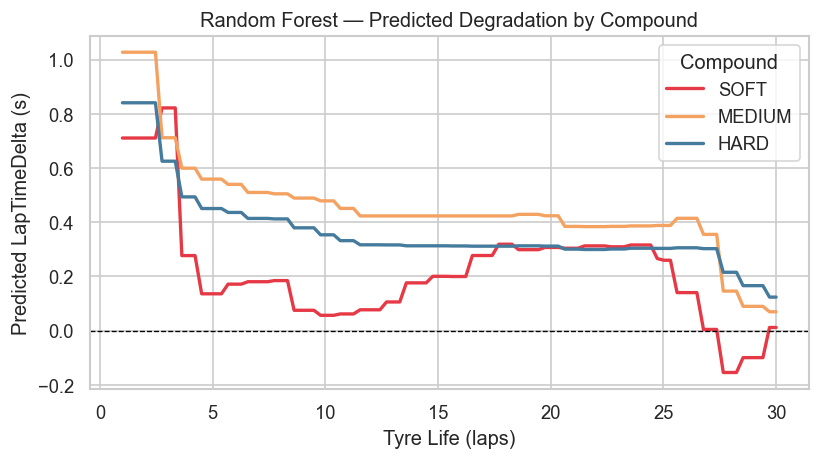

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train on 2024, test on 2025
train = df[df['Year'] == 2024].dropna(subset=['TyreLife', 'CompoundEncoded', 'LapTimeDelta'])
test  = df[df['Year'] == 2025].dropna(subset=['TyreLife', 'CompoundEncoded', 'LapTimeDelta'])

X_train, y_train = train[['TyreLife', 'CompoundEncoded']], train['LapTimeDelta']
X_test,  y_test  = test[['TyreLife', 'CompoundEncoded']],  test['LapTimeDelta']

rf     = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f'Random Forest — 2025 holdout')
print(f'  RMSE : {rmse:.3f} s')
print(f'  R²   : {r2:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
compound_colors = {'SOFT': '#e63946', 'MEDIUM': '#f4a261', 'HARD': '#457b9d'}

x = np.linspace(1, 30, 100)
for compound, color in compound_colors.items():
    enc  = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}[compound]
    pred = rf.predict(pd.DataFrame({'TyreLife': x, 'CompoundEncoded': enc}))
    ax.plot(x, pred, color=color, linewidth=2, label=compound)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Tyre Life (laps)')
ax.set_ylabel('Predicted LapTimeDelta (s)')
ax.set_title('Random Forest — Predicted Degradation by Compound')
ax.legend(title='Compound')
plt.tight_layout()
plt.savefig('plot_05_random_forest.png', bbox_inches='tight')
plt.show()


## 6. Challenges
- **Safety car edge cases**: `TrackStatus` is the most reliable flag but some partially neutralized laps still slip through. A secondary z-score filter per lap number may improve this.
- **Stint boundary noise**: The first 1–2 laps of each stint sometimes show anomalously fast times (fresh tyres + open track). We may exclude lap 1 per stint from the degradation target.
- **Per-stint median baseline**: Using stint median as the baseline for `LapTimeDelta` partially absorbs the degradation signal, contributing to the weak linear correlations observed. Alternative baselines (e.g., first-lap or rolling window) will be explored during modeling.
- **Extreme stint outliers**: MEDIUM and HARD compounds show stints reaching 70–80 laps, which likely reflect unusual race circumstances. These will need to be capped or filtered before training.

## 7. Next Steps

**Weeks 5–6 — Modeling (Kevin)**
1. Baseline Linear Regression: predict `LapTimeDelta` from `TyreLife`, `CompoundEncoded`, `TrackTemp`, `StintLength`, and circuit one-hot encoding
1. Time-based cross-validation: train on 2024 season, validate on 2025 season
1. Random Forest and XGBoost: compare RMSE and feature importances against baseline
1. Target: RMSE < 0.3s per lap on held-out 2025 races

**Weeks 7–8 — Pit-Stop Optimizer (Michael)**
1. Build race-simulation module: given predicted degradation curves, identify compound sequence and stint lengths minimizing total race time
1. Back-test against actual 2025 race outcomes — target: strategy within 2 laps of actual optimal on ≥60% of test races